In [1]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

data\interactions.csv
data\items.csv
data\sample_submission.csv
data\users.csv


# Preprocessing

In [2]:
df = pd.read_csv('./data/interactions.csv')
df_users = pd.read_csv('./data/users.csv')
df_items = pd.read_csv('./data/items.csv')
df_test = pd.read_csv('./data/sample_submission.csv')

## Interactions

In [3]:
df.head()

,user_id,item_id,progress,rating,start_date
0,90133,82910,100,NaN,2018-01-01
1,159130,331068,70,NaN,2018-01-01
2,80061,26540,69,4.0,2018-01-01
3,12811,301895,16,NaN,2018-01-01
4,5778,127872,100,NaN,2018-01-01


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1562617 entries, 0 to 1562616
Data columns (total 5 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   user_id     1562617 non-null  int64  
 1   item_id     1562617 non-null  int64  
 2   progress    1562617 non-null  int64  
 3   rating      323571 non-null   float64
 4   start_date  1562617 non-null  object 
dtypes: float64(1), int64(3), object(1)
memory usage: 59.6+ MB


In [5]:
df['start_date'] = pd.to_datetime(df['start_date'])
df['progress'] = df['progress'].astype(np.int8)

In [6]:
duplicates = df.duplicated(subset=['user_id', 'item_id'], keep=False)
df_duplicates = df[duplicates].sort_values(by=['user_id', 'start_date'])
df = df[~duplicates]

In [7]:
df_duplicates = df_duplicates.groupby(['user_id', 'item_id']).agg({
    'progress': 'max',
    'rating': 'max',
    'start_date': 'min'
})
df = df.append(df_duplicates.reset_index(drop=True), ignore_index=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1562505 entries, 0 to 1562504
Data columns (total 5 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   user_id     1562393 non-null  float64       
 1   item_id     1562393 non-null  float64       
 2   progress    1562505 non-null  int8          
 3   rating      323563 non-null   float64       
 4   start_date  1562505 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int8(1)
memory usage: 49.2 MB


## Users

In [9]:
df_users.head().append(df_users.tail())

,user_id,age,sex
0,0,45_54,1.0
1,1,25_34,0.0
2,2,45_54,0.0
3,3,65_inf,0.0
4,4,18_24,0.0
137249,166060,25_34,0.0
137250,166061,35_44,1.0
137251,166062,45_54,1.0
137252,166065,25_34,0.0
137253,166066,45_54,0.0


In [10]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137254 entries, 0 to 137253
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   user_id  137254 non-null  int64  
 1   age      137244 non-null  object 
 2   sex      135640 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 3.1+ MB


In [11]:
df_users.nunique()

user_id    137254
age             6
sex             2
dtype: int64

In [12]:
interaction_users = df['user_id'].unique()

common_users = len(np.intersect1d(interaction_users, df_users['user_id']))
users_only_in_interaction = len(np.setdiff1d(interaction_users, df_users['user_id']))
# Пользователи с фичами - те, которые есть в df_users
users_only_in_features = len(np.setdiff1d(df['user_id'], interaction_users))
total_users = common_users + users_only_in_interaction + users_only_in_features

print(f'Кол-во пользователей - {total_users}')
print(f'Кол-во пользователей со взаимодейсвтиями и фичами - {common_users} ({common_users / total_users * 100:.2f}%)')
print(f'Кол-во пользователей только со взаимодействиями - {users_only_in_interaction} ({users_only_in_interaction / total_users * 100:.2f}%)')
print(f'Кол-во пользователей только с фичами - {users_only_in_features} ({users_only_in_features / total_users * 100:.2f}%)')

Кол-во пользователей - 158438
Кол-во пользователей со взаимодейсвтиями и фичами - 130808 (82.56%)
Кол-во пользователей только со взаимодействиями - 27518 (17.37%)
Кол-во пользователей только с фичами - 112 (0.07%)


## Items

In [13]:
df_items.head()

,id,title,genres,authors,year
0,248031,Ворон-челобитчик,"Зарубежные детские книги,Сказки,Зарубежная кла...",Михаил Салтыков-Щедрин,1886
1,256084,Скрипка Ротшильда,"Классическая проза,Литература 19 века,Русская ...",Антон Чехов,1894
2,134166,Испорченные дети,"Зарубежная классика,Классическая проза,Литерат...",Михаил Салтыков-Щедрин,1869
3,281311,Странный человек,"Пьесы и драматургия,Литература 19 века",Михаил Лермонтов,1831
4,213473,Господа ташкентцы,"Зарубежная классика,Классическая проза,Литерат...",Михаил Салтыков-Щедрин,1873


In [14]:
df_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63758 entries, 0 to 63757
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       63758 non-null  int64 
 1   title    63758 non-null  object
 2   genres   63753 non-null  object
 3   authors  56700 non-null  object
 4   year     49508 non-null  object
dtypes: int64(1), object(4)
memory usage: 2.4+ MB


In [15]:
for col in ['title', 'genres', 'authors', 'year']:
    df_items[col] = df_items[col].astype(str)

In [16]:
df_items.nunique()

id         63758
title      58093
genres     11092
authors    17025
year        1075
dtype: int64

In [17]:
print('Кол-во смешанных жанров -', df_items['genres'].unique().size)
print('Реальное кол-во жанров -', len(set(np.char.split(df_items['genres'].unique().astype(str), sep=',').sum())))

Кол-во смешанных жанров - 11092
Реальное кол-во жанров - 659


In [18]:
print('Кол-во смешанных авторов -', df_items['authors'].unique().size)
print('Реальное кол-во авторов -', len(set(np.char.split(df_items['authors'].unique().astype(str), sep=',').sum())))

Кол-во смешанных авторов - 17025
Реальное кол-во авторов - 18950


In [19]:
df_items['genres'] = df_items['genres'].str.split(',')
df_items['genres'] = df_items['genres'].apply(lambda x: np.array(x))
df_items['authors'] = df_items['authors'].str.split(',')
df_items['authors'] = df_items['authors'].apply(lambda x: np.array(x))

In [20]:
df_items.head()

,id,title,genres,authors,year
0,248031,Ворон-челобитчик,"[Зарубежные детские книги, Сказки, Зарубежная ...",[Михаил Салтыков-Щедрин],1886
1,256084,Скрипка Ротшильда,"[Классическая проза, Литература 19 века, Русск...",[Антон Чехов],1894
2,134166,Испорченные дети,"[Зарубежная классика, Классическая проза, Лите...",[Михаил Салтыков-Щедрин],1869
3,281311,Странный человек,"[Пьесы и драматургия, Литература 19 века]",[Михаил Лермонтов],1831
4,213473,Господа ташкентцы,"[Зарубежная классика, Классическая проза, Лите...",[Михаил Салтыков-Щедрин],1873


In [21]:
df_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63758 entries, 0 to 63757
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       63758 non-null  int64 
 1   title    63758 non-null  object
 2   genres   63758 non-null  object
 3   authors  63758 non-null  object
 4   year     63758 non-null  object
dtypes: int64(1), object(4)
memory usage: 2.4+ MB


In [22]:
interaction_items = df['item_id'].unique()

common_items = len(np.intersect1d(interaction_items, df_items['id']))
items_only_in_interaction = len(np.setdiff1d(interaction_items, df_items['id']))
items_only_in_features = len(np.setdiff1d(df_items['id'], interaction_items))
total_items = common_items + items_only_in_interaction + items_only_in_features

print(f'Кол-во книг - {total_items}')
print(f'Кол-во книг со взаимодействиями и фичами - {common_items} ({common_items / total_items * 100:.2f}%)')
print(f'Кол-во книг только со взаимодействиями - {items_only_in_interaction} ({items_only_in_interaction / total_items * 100:.2f}%)')
print(f'Кол-во книг только с фичами - {items_only_in_features} ({items_only_in_features / total_items * 100:.2f}%)')

Кол-во книг - 63759
Кол-во книг со взаимодействиями и фичами - 63758 (100.00%)
Кол-во книг только со взаимодействиями - 1 (0.00%)
Кол-во книг только с фичами - 0 (0.00%)


# Metric
## map@K

In [23]:
df_true = pd.DataFrame({
    'user_id': ['Аня', 'Боря', 'Вася', 'Вася'],
    'item_id': ['Мастер и Маргарита', '451 по Фаренгейту', 'Зеленая миля', 
                'Рита Хейуорт и спасение из Шоушенка']
})
df_true

,user_id,item_id
0,Аня,Мастер и Маргарита
1,Боря,451 по Фаренгейту
2,Вася,Зеленая миля
3,Вася,Рита Хейуорт и спасение из Шоушенка


In [24]:
df_recs = pd.DataFrame({
    'user_id': [
        'Аня', 'Аня', 'Аня', 
        'Боря', 'Боря', 'Боря', 
        'Вася', 'Вася', 'Вася'
    ],
    'item_id': [
        'Отверженные', 'Двенадцать стульев', 'Герои нашего времени', 
        '451 по Фаренгейту', '1984', 'О дивный новый мир',
        'Десять негритят', 'Рита Хейуорт и спасение из Шоушенка', 'Зеленая миля'
    ],
    'rank': [
        1, 2, 3,
        1, 2, 3,
        1, 2, 3
    ]
})
df_recs

,user_id,item_id,rank
0,Аня,Отверженные,1
1,Аня,Двенадцать стульев,2
2,Аня,Герои нашего времени,3
3,Боря,451 по Фаренгейту,1
4,Боря,1984,2
5,Боря,О дивный новый мир,3
6,Вася,Десять негритят,1
7,Вася,Рита Хейуорт и спасение из Шоушенка,2
8,Вася,Зеленая миля,3


In [25]:
df_merged = df_true.set_index(['user_id', 'item_id']).join(df_recs.set_index(['user_id', 'item_id']), how='left')
df_merged = df_merged.sort_values(by=['user_id', 'rank'])
df_merged

rank
user_id item_id                                  
Аня     Мастер и Маргарита                    NaN
Боря    451 по Фаренгейту                     1.0
Вася    Рита Хейуорт и спасение из Шоушенка   2.0
        Зеленая миля                          3.0

In [26]:
df_merged['cumulative_rank'] = df_merged.groupby(level='user_id').cumcount() + 1
df_merged['cumulative_rank'] = df_merged['cumulative_rank'] / df_merged['rank']
df_merged['users_item_count'] = df_merged.groupby(level='user_id')['rank'].transform(np.size)
df_merged

rank  cumulative_rank  \
user_id item_id                                                      
Аня     Мастер и Маргарита                    NaN              NaN   
Боря    451 по Фаренгейту                     1.0         1.000000   
Вася    Рита Хейуорт и спасение из Шоушенка   2.0         0.500000   
        Зеленая миля                          3.0         0.666667   

                                             users_item_count  
user_id item_id                                                
Аня     Мастер и Маргарита                                1.0  
Боря    451 по Фаренгейту                                 1.0  
Вася    Рита Хейуорт и спасение из Шоушенка               2.0  
        Зеленая миля                                      2.0

In [27]:
users_count = df_merged.index.get_level_values('user_id').nunique()
map3 = (df_merged['cumulative_rank'] / df_merged['users_item_count']).sum() / users_count
print(f'MAP@3 = {map3}')

MAP@3 = 0.5277777777777778


# EDA

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

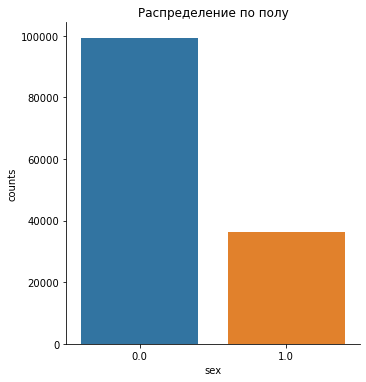

In [110]:
users_by_sex = df_users['sex'].value_counts().reset_index()
users_by_sex.columns = ['sex', 'counts']
sns.catplot(x='sex', y='counts', kind='bar', 
            data=users_by_sex).set(title='Распределение по полу')
None

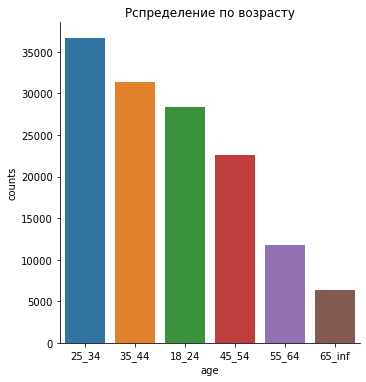

In [113]:
users_by_age = df_users['age'].value_counts().reset_index()
users_by_age.columns = ['age', 'counts']
sns.catplot(x='age', y='counts', kind='bar', 
            data=users_by_age).set(title='Рспределение по возрасту')
None

In [29]:
%%time
df_merged = df.merge(df_users, on='user_id')
df_merged = df_merged.merge(df_items, left_on='item_id', right_on='id')
df_merged = df_merged.sort_values(by='start_date')
df_merged.head()

Wall time: 5.25 s


,user_id,item_id,progress,rating,start_date,age,sex,id,title,genres,authors,year
0,90133.0,82910.0,100,NaN,2018-01-01,55_64,0.0,82910,Ведьма отмщения,[Современные детективы],[Галина Романова],2013
533820,165810.0,19060.0,25,NaN,2018-01-01,35_44,0.0,19060,"Секс, водка, потанцуем? Природа удовольствий","[Научно-популярная литература, Нейропсихология...",[Виктория Канела],2014
402034,138368.0,326545.0,43,NaN,2018-01-01,35_44,0.0,326545,"Экспресс-маркетинг. Быстро, конкретно, прибыльно","[Привлечение клиентов, Российская практика, Па...",[Александр Левитас],2016
401779,114825.0,168383.0,62,5.0,2018-01-01,18_24,0.0,168383,Кулинарная энциклопедия. Том 34. С (Сливки – С...,"[Кулинария, Энциклопедии]",[nan],2017
675790,64701.0,283557.0,17,NaN,2018-01-01,45_54,0.0,283557,Добрые Советы. Домашний Доктор 01-2020,[Здоровье],[nan],2019


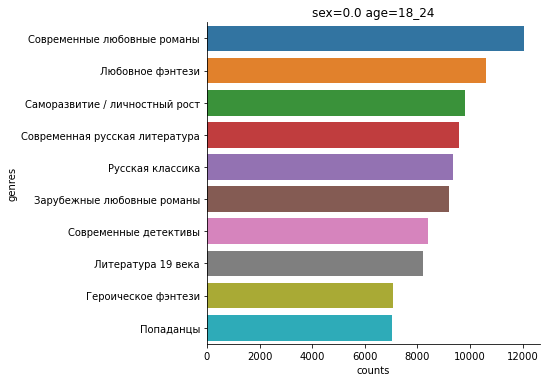

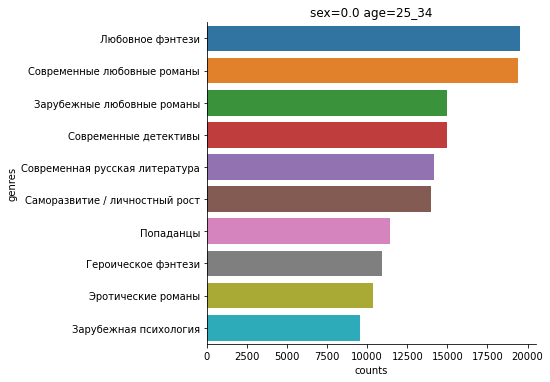

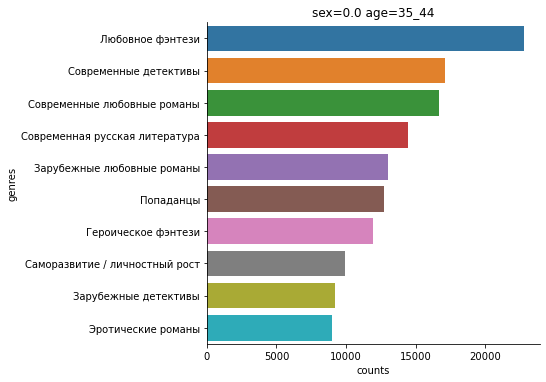

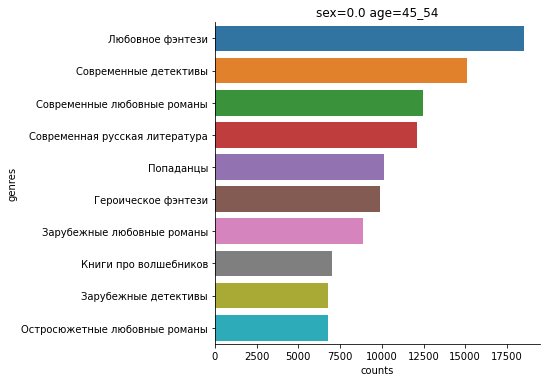

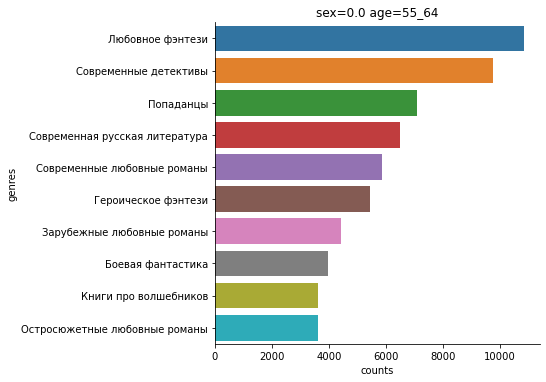

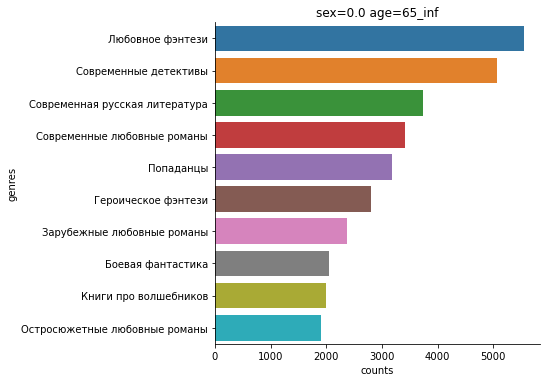

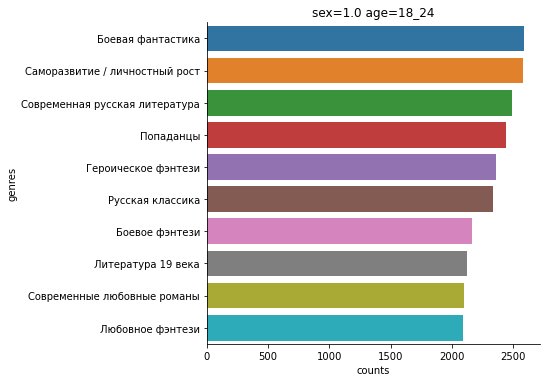

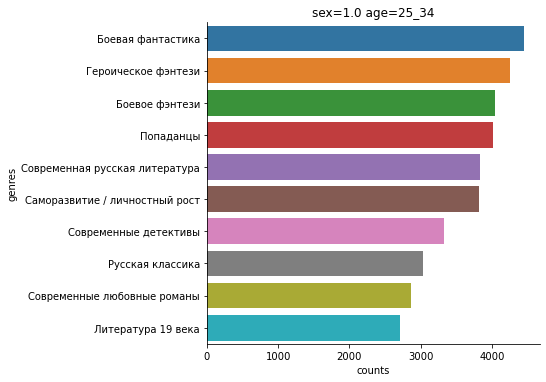

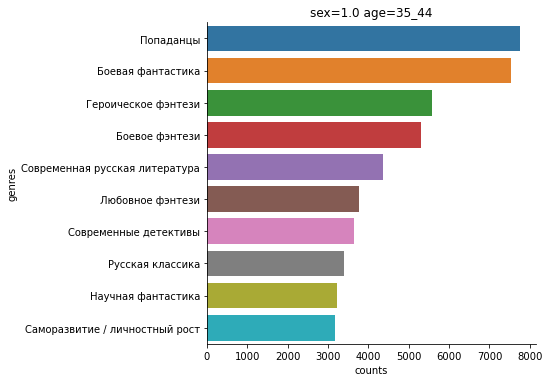

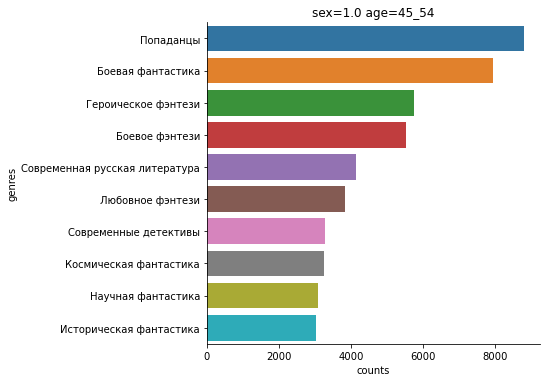

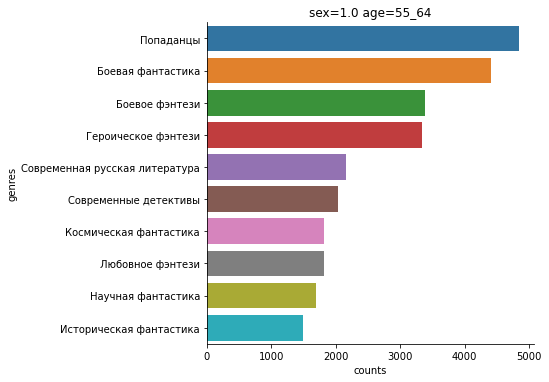

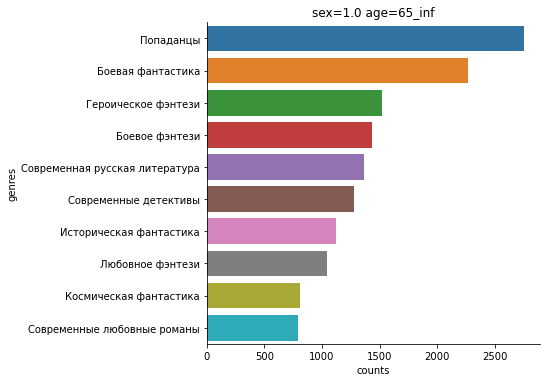

In [30]:
for (sex, age), group in df_merged.groupby(['sex', 'age'])['genres']:
    genres, counts = np.unique(np.concatenate(group.values), return_counts=True)
    df_unique = pd.DataFrame({'genres': genres, 'counts':counts})
    df_unique = df_unique.sort_values(by='counts', ascending=False).head(10)
    df_unique['sex'] = [sex] * 10
    df_unique['age'] = [age] * 10
    sns.catplot(x='counts', y='genres', orient='h', data=df_unique, kind='bar', 
                aspect=1.5).set(title=f'sex={sex} age={age}')

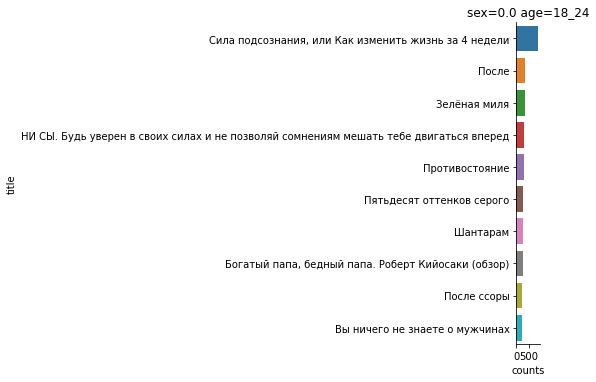

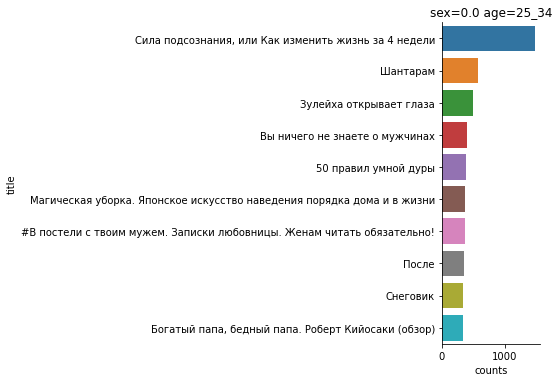

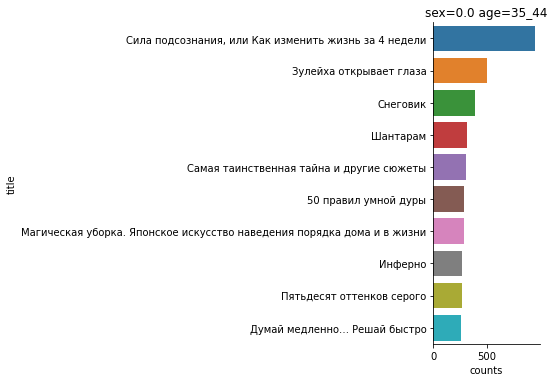

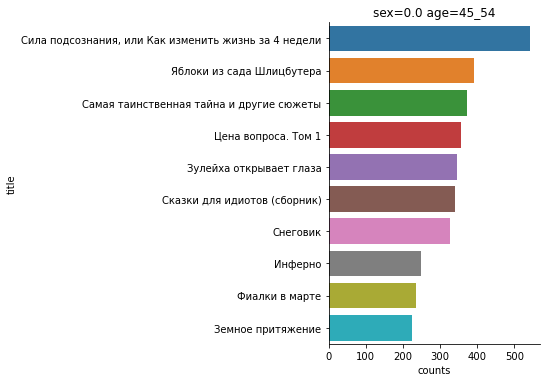

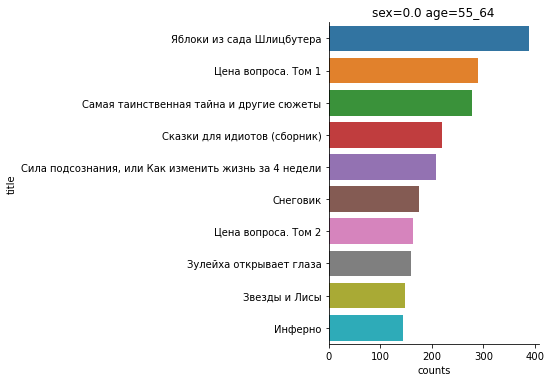

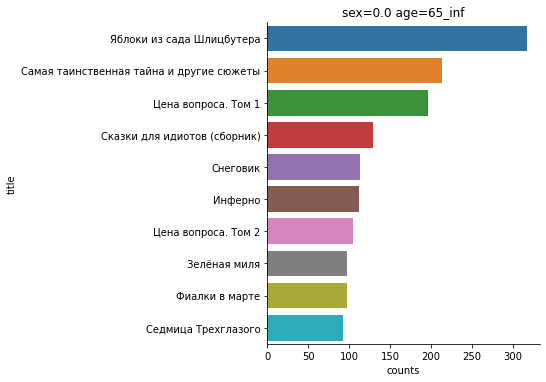

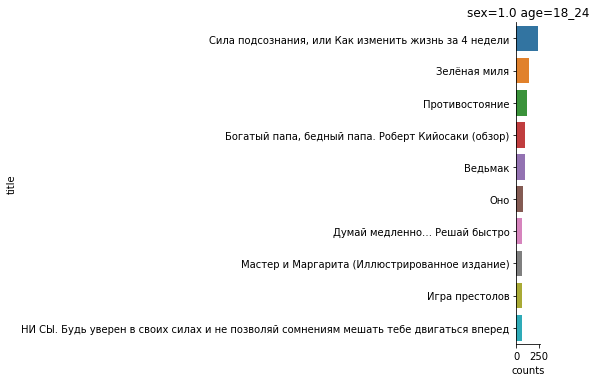

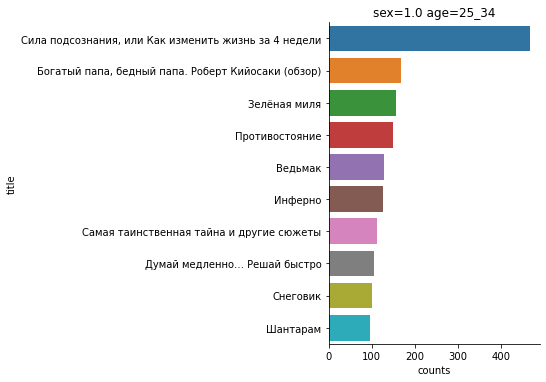

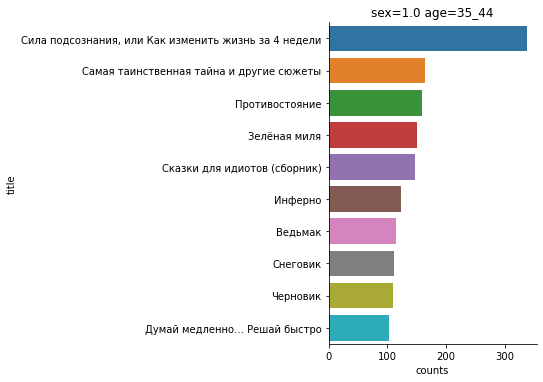

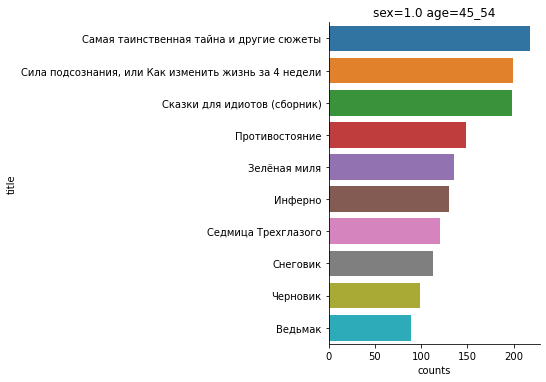

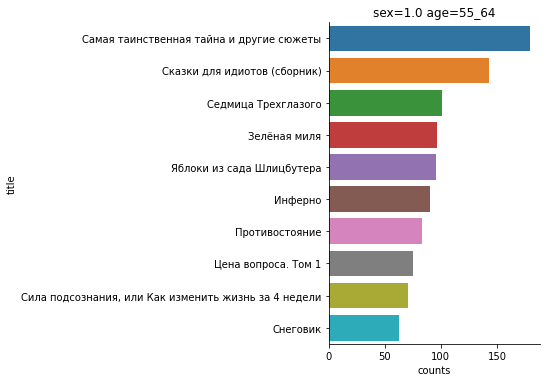

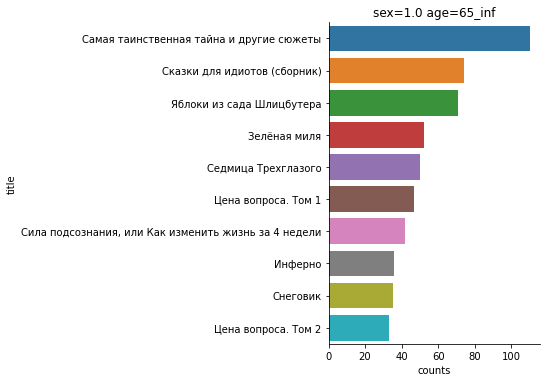

In [31]:
for (sex, age), group in df_merged.groupby(['sex', 'age'])['title']:
    df_unique = group.value_counts().head(10).reset_index()
    df_unique.columns = ['title', 'counts']
    df_unique['sex'] = [sex] * 10
    df_unique['age'] = [age] * 10
    sns.catplot(x='counts', y='title', orient='h', data=df_unique, kind='bar', 
                aspect=1.5).set(title=f'sex={sex} age={age}')

# Predict

In [38]:
df_users['age'].unique()

array(['45_54', '25_34', '65_inf', '18_24', '35_44', '55_64', nan],
      dtype=object)

In [193]:
class GroupPopularRecommender():
    def __init__(self, max_K=10, item_column='item_id', user_column = 'user_id', sex='sex', age='age'):
        self.max_K = max_K
        self.item_column = item_column
        self.user_column = user_column
        self.sex = sex
        self.age = age
        self.recommendations = pd.DataFrame(index=[0, 1], 
                                            columns=['18_24', '25_34', 
                                                     '35_44', '45_54', 
                                                     '55_64', '65_inf'])
    
    def fit(self, df):
        self.df = df
        for (sex, age), group in df.groupby([self.sex, self.age])[self.item_column]:
            df_unique = group.value_counts().head(self.max_K).reset_index()
            df_unique.columns = ['item_id', 'counts']
            self.recommendations.loc[sex, age] = ' '.join(df_unique[self.item_column].astype(int).astype(str))
            
    def recommend(self, users):
        recs = []
        sex, age = 0, '25_34'
        self.df = self.df.fillna({'sex': 0, 'age': '25_34'})
        for user in users:
            try:
                interaction = self.df[self.df[self.user_column] == user].iloc[0]
                sex, age = interaction['sex'], interaction['age']
            except IndexError:
                pass
            recs.append(self.recommendations.loc[sex, age])
        return recs

In [194]:
df_test.head()

,Id,Predicted
0,10001,178529 80003 352701 262464 80398 385281 354482...
1,10002,178529 80003 352701 262464 80398 385281 354482...
2,100152,178529 80003 352701 262464 80398 385281 354482...
3,100197,178529 80003 352701 262464 80398 385281 354482...
4,100284,178529 283713 184549 276903 126630 352049 5546...


In [201]:
model = GroupPopularRecommender()
model.fit(df_merged.iloc[-40000:])

In [202]:
%%time
df_test['Predicted'] = model.recommend(df_test['Id'])
df_test.head()

Wall time: 5.93 s


,Id,Predicted
0,10001,56877 80003 357309 276903 262464 184549 334106...
1,10002,56877 80003 357309 276903 262464 184549 334106...
2,100152,56877 80003 357309 276903 262464 184549 334106...
3,100197,56877 80003 357309 276903 262464 184549 334106...
4,100284,56877 80003 357309 276903 262464 184549 334106...


In [203]:
df_test.to_csv('grouppop_submission.csv', index=False)